In [4]:
# --- Imports and Parameters ---
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

# Time window for timestamps
start_time = datetime(2025, 1, 1, 0, 0, 0)
end_time = start_time + timedelta(days=1)

# Global variation settings
bucket_fill_variation = 0.15  # +/- 15%
cycle_time_variation = 0.12   # +/- 12%

# Specific gravity for each material type (t/m³)
material_sg = {
    "ore1": 2.7, "ore2": 2.8, "ore3": 2.65, "waste": 2.2
}

# Loader specs with targets
loader_cycle_specs = {
    "kom_pc8000": {
        "make": "Komatsu", "model": "PC8000", "bucket_capacity_m3": 42,
        "cycle_time_target_sec": 32, "bucket_fill_target": 0.90
    },
    "lie_r9800": {
        "make": "Liebherr", "model": "R 9800", "bucket_capacity_m3": 42,
        "cycle_time_target_sec": 31, "bucket_fill_target": 0.92
    },
    "cat_6060": {
        "make": "Caterpillar", "model": "6060", "bucket_capacity_m3": 34,
        "cycle_time_target_sec": 35, "bucket_fill_target": 0.88
    },
    "hit_ex8000": {
        "make": "Hitachi", "model": "EX8000", "bucket_capacity_m3": 43,
        "cycle_time_target_sec": 33, "bucket_fill_target": 0.91
    }
}

# Truck types and assignments
truck_specs = {
    "truck_1": "cat_793f", "truck_2": "kom_930e", "truck_3": "hit_eh5000",
    "truck_4": "lie_t284", "truck_5": "bel_75710"
}
truck_id_list = list(truck_specs.keys())

# Loaders and their types
loading_unit_specs = {
    "loader_1": "kom_pc8000", "loader_2": "lie_r9800",
    "loader_3": "cat_6060", "loader_4": "hit_ex8000"
}
loading_unit_list = list(loading_unit_specs.keys())

# Other parameters
material_types = ['ore1', 'ore2', 'ore3', 'waste']
stockpiles = [f"stockpile_{i}" for i in range(1, 4)]
waste_dumps = [f"waste_dump_{i}" for i in range(1, 3)]
load_location_list = [f"pit_{i}" for i in range(1, 6)]
pit_ids = ['a', 'b', 'c', 'd', 'e']
default_p80_unit = "mm"


In [5]:
# --- Generate Blasts ---
blasts = {}
for pit in pit_ids:
    for rl in range(100, 111):
        for pattern in range(1, 4):
            blast_id = f"{pit}{rl:03d}-{pattern:03d}"
            mat_type = random.choice(material_types)
            sg = material_sg[mat_type]
            volume_m3 = random.randint(3000, 7500)
            volume_t = int(volume_m3 * sg)
            blasts[blast_id] = {
                "pit": pit, "rl": rl, "pattern": pattern,
                "material_type": mat_type, "volume_m3": volume_m3, "volume_t": volume_t,
                "sg": sg, "unit": "t",
                "au": round(np.random.uniform(0.5, 2.0), 2) if mat_type != 'waste' else 0.0,
                "cu": round(np.random.uniform(0.1, 0.3), 2) if mat_type != 'waste' else 0.0,
                "ag": round(np.random.uniform(1.0, 5.0), 2) if mat_type != 'waste' else 0.0,
                "s": round(np.random.uniform(1.0, 3.0), 2) if mat_type != 'waste' else 0.3
            }


In [6]:
# --- Generate Synthetic FMS Data ---
records = []

for blast_id, props in blasts.items():
    num_buckets = int(props['volume_t'] / 12)  # Approx. 12t per bucket
    for _ in range(num_buckets):
        loader_id = random.choice(loading_unit_list)
        loader_type = loading_unit_specs[loader_id]
        spec = loader_cycle_specs[loader_type]

        # Apply variations
        actual_fill = np.clip(np.random.uniform(
            spec["bucket_fill_target"] * (1 - bucket_fill_variation),
            spec["bucket_fill_target"] * (1 + bucket_fill_variation)
        ), 0, 1)

        actual_cycle_sec = np.clip(np.random.uniform(
            spec["cycle_time_target_sec"] * (1 - cycle_time_variation),
            spec["cycle_time_target_sec"] * (1 + cycle_time_variation)
        ), 15, 60)

        # Calculate values
        bucket_volume_m3 = spec["bucket_capacity_m3"] * actual_fill
        cycle_time_min = actual_cycle_sec / 60.0
        digability = bucket_volume_m3 / cycle_time_min

        record = {
            "timestamp": start_time + timedelta(seconds=random.randint(0, 86400)),
            "pit": props['pit'],
            "blast_id": blast_id,
            "truck_id": random.choice(truck_id_list),
            "loading_unit_id": loader_id,
            "cycle_time_minutes": round(cycle_time_min, 3),
            "digability": round(digability, 3),
            "bucket_volume_m3": round(bucket_volume_m3, 2),
            "material_type": props['material_type'],
            "tonnage_moved_t": np.clip(np.random.normal(loc=12, scale=2), 5, None),
            "load_location": random.choice(load_location_list),
            "dump_location": random.choice(stockpiles) if props['material_type'] != 'waste' else random.choice(waste_dumps),
            "au_grade_gpt": props['au'],
            "cu_grade_pct": props['cu'],
            "ag_grade_gpt": props['ag'],
            "s_grade_pct": props['s'],
            "latitude": np.random.uniform(-21.2, -21.0),
            "longitude": np.random.uniform(119.6, 119.8),
            "z": np.random.uniform(350, 550),
            "sg": props['sg'],
            "throughput_tph": None,
            "p80": None,
            "p80_unit": default_p80_unit
        }

        records.append(record)

# Assemble DataFrame
df_synthetic_fms = pd.DataFrame(records)


In [7]:
# Preview first few rows
df_synthetic_fms.head()

# Optionally save to CSV
# df_synthetic_fms.to_csv("synthetic_fms_data.csv", index=False)


,timestamp,pit,blast_id,truck_id,loading_unit_id,cycle_time_minutes,digability,bucket_volume_m3,material_type,tonnage_moved_t,...,cu_grade_pct,ag_grade_gpt,s_grade_pct,latitude,longitude,z,sg,throughput_tph,p80,p80_unit
0,2025-01-01 12:52:37,a,a100-001,truck_5,loader_1,0.479,80.847,38.75,ore1,12.683512,...,0.29,3.93,2.2,-21.138094,119.762759,486.946235,2.7,None,None,mm
1,2025-01-01 08:37:09,a,a100-001,truck_2,loader_2,0.568,61.183,34.73,ore1,15.752342,...,0.29,3.93,2.2,-21.035493,119.789960,495.143902,2.7,None,None,mm
2,2025-01-01 06:31:49,a,a100-001,truck_3,loader_1,0.523,74.753,39.09,ore1,14.358880,...,0.29,3.93,2.2,-21.002545,119.630083,468.826143,2.7,None,None,mm
3,2025-01-01 09:42:50,a,a100-001,truck_2,loader_2,0.575,64.806,37.26,ore1,11.061649,...,0.29,3.93,2.2,-21.031576,119.767666,443.738632,2.7,None,None,mm
4,2025-01-01 17:08:14,a,a100-001,truck_2,loader_1,0.504,73.036,36.83,ore1,12.010487,...,0.29,3.93,2.2,-21.046203,119.788953,519.929478,2.7,None,None,mm


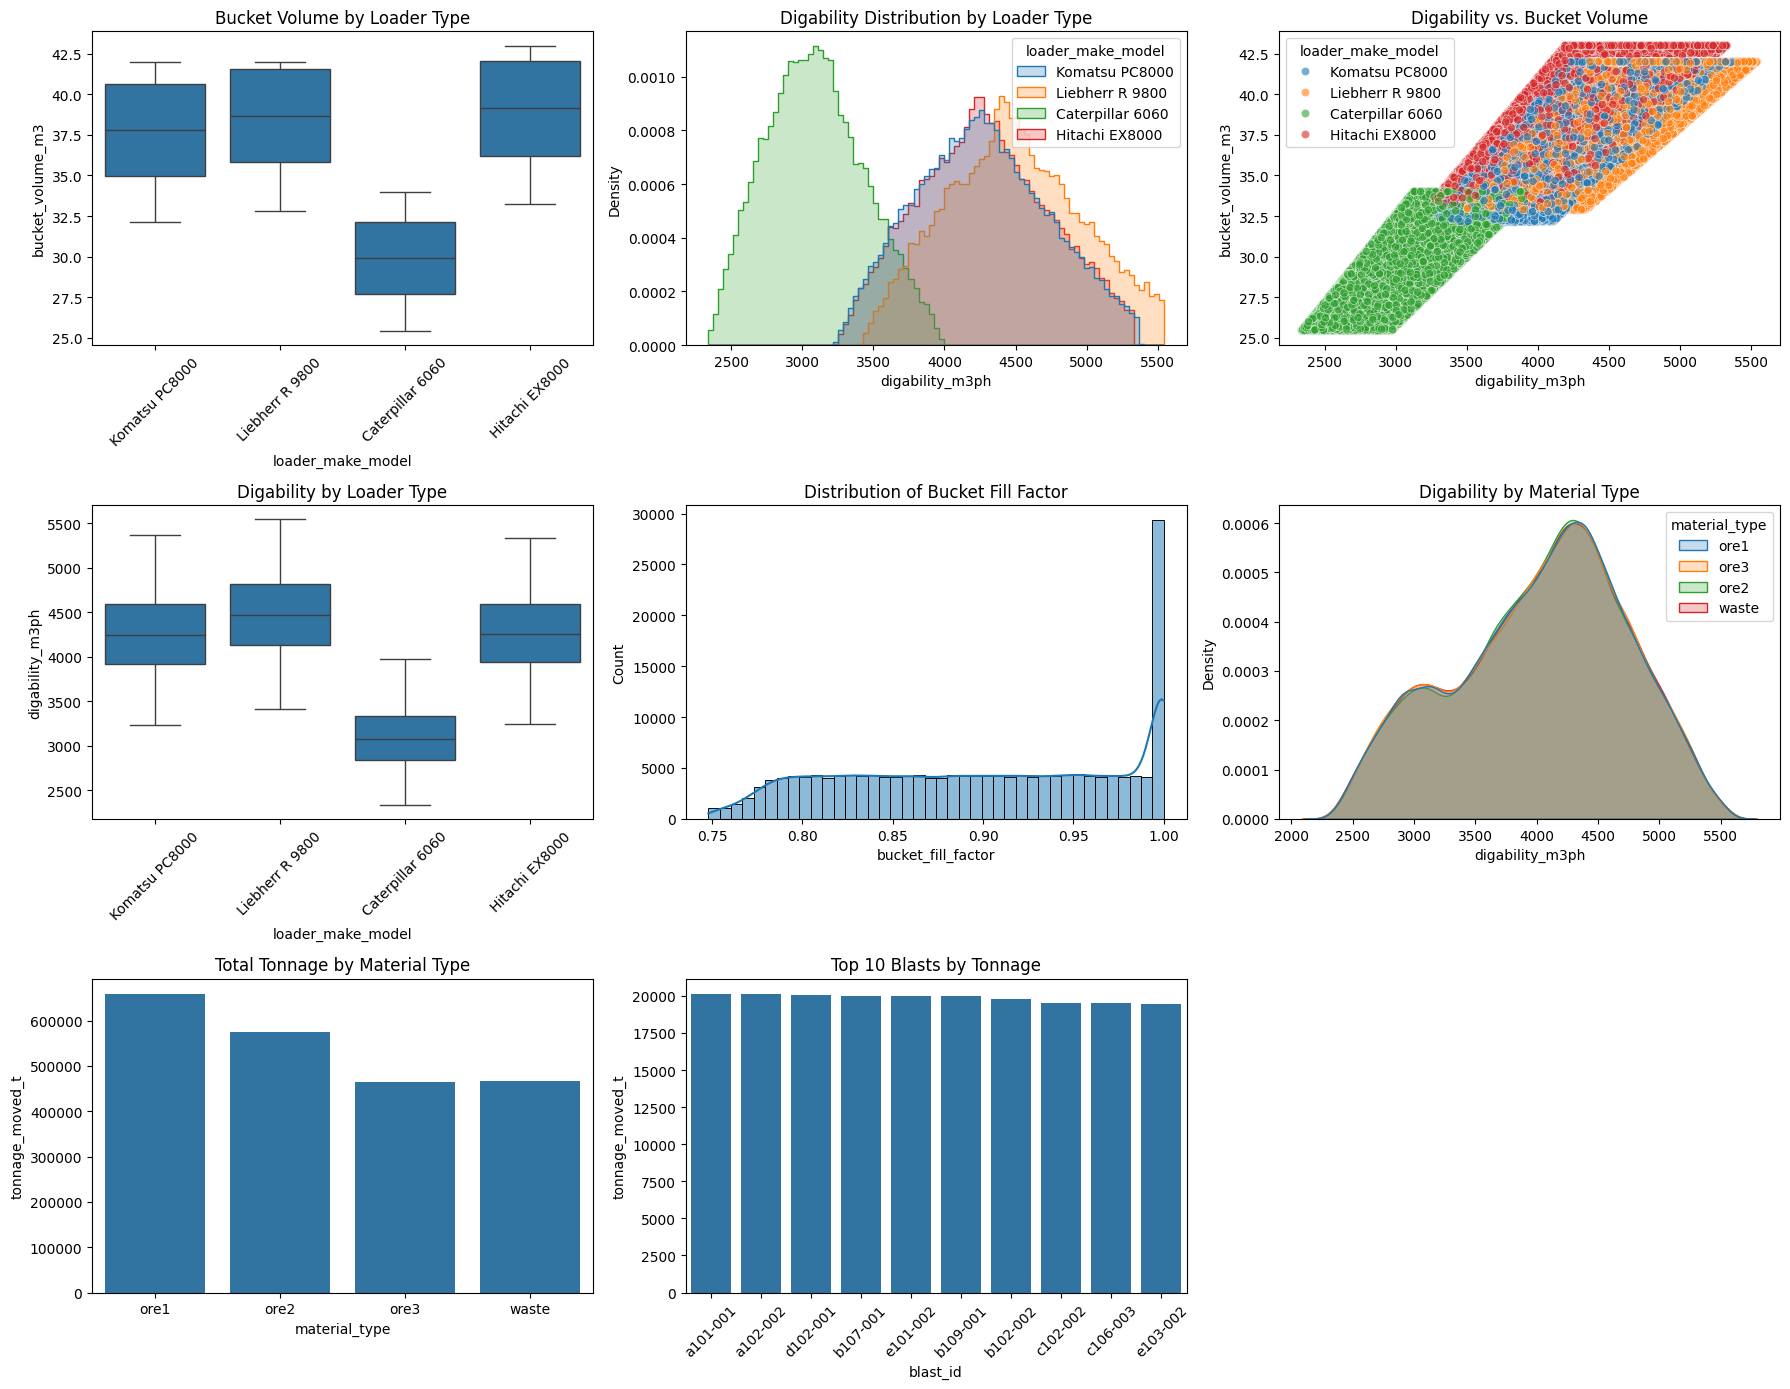

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Derived Fields ---
df_synthetic_fms["digability_m3ph"] = df_synthetic_fms["digability"] * 60

# Map loader_id to make & model
loader_labels = {
    k: f"{loader_cycle_specs[v]['make']} {loader_cycle_specs[v]['model']}"
    for k, v in loading_unit_specs.items()
}
df_synthetic_fms["loader_make_model"] = df_synthetic_fms["loading_unit_id"].map(loader_labels)

# Bucket fill factor from known capacity
def get_capacity(loader_id):
    loader_type = loading_unit_specs[loader_id]
    return loader_cycle_specs[loader_type]["bucket_capacity_m3"]

df_synthetic_fms["bucket_capacity_m3"] = df_synthetic_fms["loading_unit_id"].apply(get_capacity)
df_synthetic_fms["bucket_fill_factor"] = df_synthetic_fms["bucket_volume_m3"] / df_synthetic_fms["bucket_capacity_m3"]

# --- Plot Layout ---
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 14))
axes = axes.flatten()

# 1. Boxplot: Bucket Volume by Loader Type
sns.boxplot(data=df_synthetic_fms, x="loader_make_model", y="bucket_volume_m3", ax=axes[0])
axes[0].set_title("Bucket Volume by Loader Type")
axes[0].tick_params(axis='x', rotation=45)

# 2. Distribution of Digability (m3/hr) by Loader
sns.histplot(data=df_synthetic_fms, x="digability_m3ph", hue="loader_make_model",
             element="step", stat="density", common_norm=False, ax=axes[1])
axes[1].set_title("Digability Distribution by Loader Type")

# 3. Digability vs Bucket Volume
sns.scatterplot(data=df_synthetic_fms, x="digability_m3ph", y="bucket_volume_m3",
                hue="loader_make_model", ax=axes[2], alpha=0.6)
axes[2].set_title("Digability vs. Bucket Volume")

# 4. Boxplot: Digability by Loader
sns.boxplot(data=df_synthetic_fms, x="loader_make_model", y="digability_m3ph", ax=axes[3])
axes[3].set_title("Digability by Loader Type")
axes[3].tick_params(axis='x', rotation=45)

# 5. Distribution of Bucket Fill Factors
sns.histplot(data=df_synthetic_fms, x="bucket_fill_factor", bins=40, kde=True, ax=axes[4])
axes[4].set_title("Distribution of Bucket Fill Factor")

# 6. Distribution of Digability by Material Type
sns.kdeplot(data=df_synthetic_fms, x="digability_m3ph", hue="material_type", fill=True, common_norm=False, ax=axes[5])
axes[5].set_title("Digability by Material Type")

# 7. Volume (Tonnage) by Material Type
material_vol = df_synthetic_fms.groupby("material_type")["tonnage_moved_t"].sum().reset_index()
sns.barplot(data=material_vol, x="material_type", y="tonnage_moved_t", ax=axes[6])
axes[6].set_title("Total Tonnage by Material Type")

# 8. Volume (Tonnage) by Blast ID - Top 10
blast_vol = df_synthetic_fms.groupby("blast_id")["tonnage_moved_t"].sum().nlargest(10).reset_index()
sns.barplot(data=blast_vol, x="blast_id", y="tonnage_moved_t", ax=axes[7])
axes[7].set_title("Top 10 Blasts by Tonnage")
axes[7].tick_params(axis='x', rotation=45)

# Hide any unused axes
if len(axes) > 8:
    axes[8].axis("off")

plt.tight_layout()
plt.show()


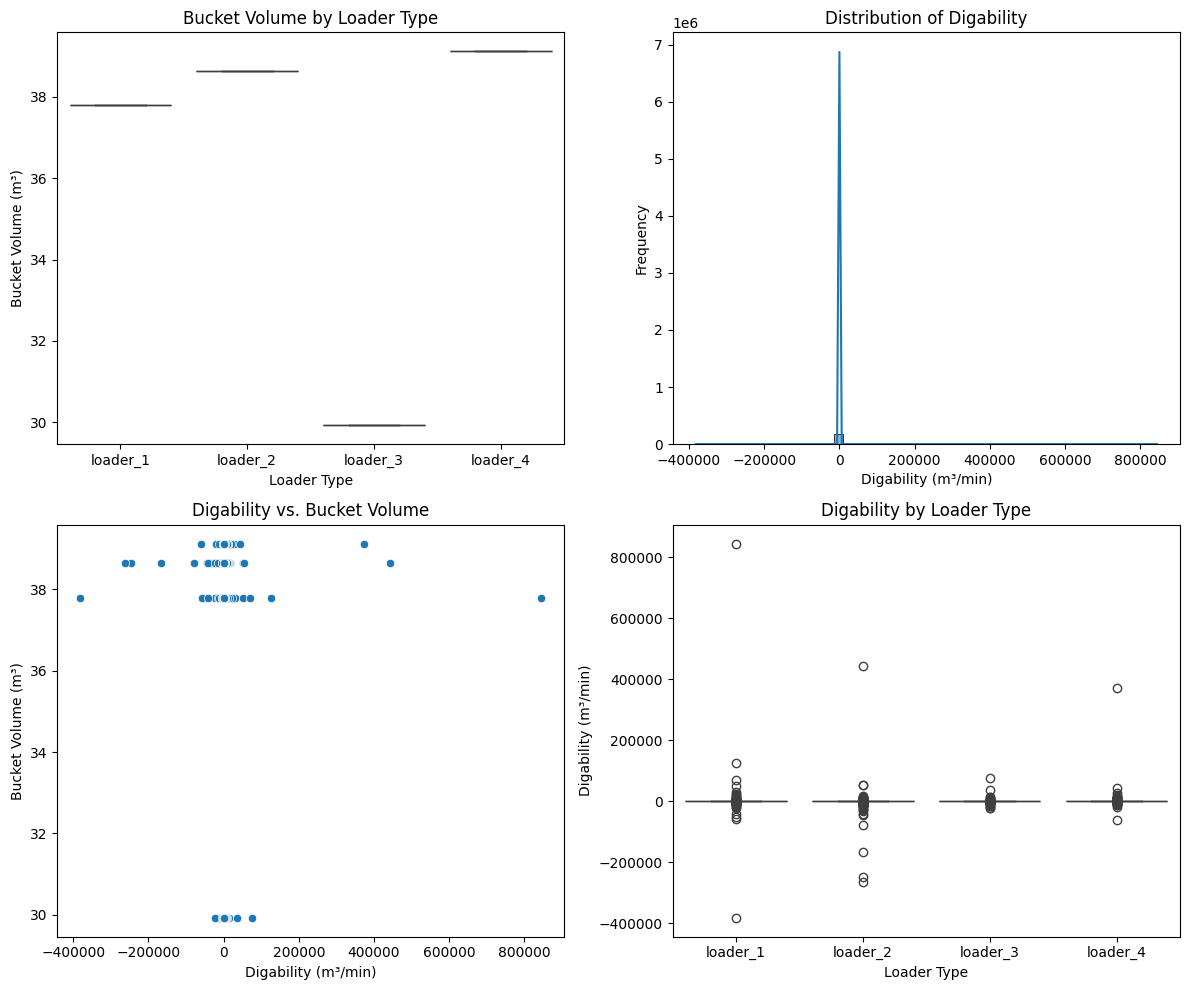

In [ ]:
# --- Parameters ---
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

# Time window for timestamps
start_time = datetime(2025, 1, 1, 0, 0, 0)
end_time = start_time + timedelta(days=1)

# Define specific gravity for each material type (t/m3)
material_sg = {
    "ore1": 2.7,
    "ore2": 2.8,
    "ore3": 2.65,
    "waste": 2.2
}

# Define estimated cycle times for each loader (based on manufacturer specs)
loader_cycle_specs = {
    "kom_pc8000": {
        "make": "Komatsu",
        "model": "PC8000",
        "bucket_capacity_m3": 42,
        "cycle_time_target_sec": 32,
        "bucket_fill_target": 0.90
    },
    "lie_r9800": {
        "make": "Liebherr",
        "model": "R 9800",
        "bucket_capacity_m3": 42,
        "cycle_time_target_sec": 31,
        "bucket_fill_target": 0.92
    },
    "cat_6060": {
        "make": "Caterpillar",
        "model": "6060",
        "bucket_capacity_m3": 34,
        "cycle_time_target_sec": 35,
        "bucket_fill_target": 0.88
    },
    "hit_ex8000": {
        "make": "Hitachi",
        "model": "EX8000",
        "bucket_capacity_m3": 43,
        "cycle_time_target_sec": 33,
        "bucket_fill_target": 0.91
    }
}

# Global variation settings for bucket fill factor and cycle times
bucket_fill_variation = 0.15  # +/- 15% variation on bucket fill factor
cycle_time_variation = 0.12   # +/- 12% variation on cycle time

# New fields to be added (placeholders)
default_p80_unit = "mm"

# Define truck types
truck_types = {
    "cat_793f": {"make": "Caterpillar", "model": "793F", "capacity": 227, "capacity_unit": "t"},
    "kom_930e": {"make": "Komatsu", "model": "930E", "capacity": 290, "capacity_unit": "t"},
    "hit_eh5000": {"make": "Hitachi", "model": "EH5000AC-3", "capacity": 296, "capacity_unit": "t"},
    "lie_t284": {"make": "Liebherr", "model": "T 284", "capacity": 363, "capacity_unit": "t"},
    "bel_75710": {"make": "BelAZ", "model": "75710", "capacity": 450, "capacity_unit": "t"},
}

# Define trucks with type references
truck_specs = {
    "truck_1": "cat_793f",
    "truck_2": "kom_930e",
    "truck_3": "hit_eh5000",
    "truck_4": "lie_t284",
    "truck_5": "bel_75710",
}
truck_id_list = list(truck_specs.keys())

# Define loading unit types
loading_unit_types = {
    "kom_pc8000": {"make": "Komatsu", "model": "PC8000", "bucket_capacity": 42, "capacity_unit": "m3"},
    "lie_r9800": {"make": "Liebherr", "model": "R 9800", "bucket_capacity": 42, "capacity_unit": "m3"},
    "cat_6060": {"make": "Caterpillar", "model": "6060", "bucket_capacity": 34, "capacity_unit": "m3"},
    "hit_ex8000": {"make": "Hitachi", "model": "EX8000", "bucket_capacity": 43, "capacity_unit": "m3"},
}

# Define loading units with type references
loading_unit_specs = {
    "loader_1": "kom_pc8000",
    "loader_2": "lie_r9800",
    "loader_3": "cat_6060",
    "loader_4": "hit_ex8000",
}
loading_unit_list = list(loading_unit_specs.keys())

material_types = ['ore1', 'ore2', 'ore3', 'waste']
stockpiles = [f"stockpile_{i}" for i in range(1, 4)]
waste_dumps = [f"waste_dump_{i}" for i in range(1, 3)]
load_location_list = [f"pit_{i}" for i in range(1, 6)]
pit_ids = ['a', 'b', 'c', 'd', 'e']

# Define blasts with dynamic volumes and grades
blasts = {}
for pit in pit_ids:
    for rl in range(100, 111):
        for pattern in range(1, 4):
            blast_id = f"{pit}{rl:03d}-{pattern:03d}"
            mat_type = random.choice(material_types)
            sg = material_sg[mat_type]
            volume_m3 = random.randint(3000, 7500)  # m3
            volume_t = int(volume_m3 * sg)         # t
            blasts[blast_id] = {
                "pit": pit,
                "rl": rl,
                "pattern": pattern,
                "material_type": mat_type,
                "volume_m3": volume_m3,
                "volume_t": volume_t,
                "sg": sg,
                "unit": "t",
                "au": round(np.random.uniform(0.5, 2.0), 2) if mat_type != 'waste' else 0.0,
                "cu": round(np.random.uniform(0.1, 0.3), 2) if mat_type != 'waste' else 0.0,
                "ag": round(np.random.uniform(1.0, 5.0), 2) if mat_type != 'waste' else 0.0,
                "s": round(np.random.uniform(1.0, 3.0), 2) if mat_type != 'waste' else 0.3
            }

# --- Data Generation ---

records = []

for blast_id, props in blasts.items():
    num_buckets = int(props['volume_t'] / 12)
    for _ in range(num_buckets):
        loader_id = random.choice(loading_unit_list)
        loader_type = loading_unit_specs[loader_id]
        loader_spec = loader_cycle_specs[loader_type]

        # Apply bucket fill factor
        bucket_fill_factor = bucket_fill_factors[loader_type]
        bucket_volume_m3 = loader_spec['bucket_capacity_m3'] * bucket_fill_factor  

        cycle_time_minutes = loader_spec['cycle_time_sec'] / 60.0 + np.random.normal(0, 0.2)  # variation
        digability = bucket_volume_m3 / cycle_time_minutes  # digability calculation

        record = {
            "timestamp": start_time + timedelta(seconds=random.randint(0, 86400)),
            "pit": props['pit'],
            "blast_id": blast_id,
            "truck_id": random.choice(truck_id_list),
            "loading_unit_id": loader_id,
            "cycle_time_minutes": round(cycle_time_minutes, 3),
            "digability": round(digability, 3),
            "bucket_volume_m3": round(bucket_volume_m3, 2),
            "material_type": props['material_type'],
            "tonnage_moved_t": np.clip(np.random.normal(loc=12, scale=2), 5, None),
            "load_location": random.choice(load_location_list),
            "dump_location": random.choice(stockpiles) if props['material_type'] != 'waste' else random.choice(waste_dumps),
            "au_grade_gpt": props['au'],
            "cu_grade_pct": props['cu'],
            "ag_grade_gpt": props['ag'],
            "s_grade_pct": props['s'],
            "latitude": np.random.uniform(-21.2, -21.0),
            "longitude": np.random.uniform(119.6, 119.8),
            "z": np.random.uniform(350, 550),
            "sg": props['sg'],
            "throughput_tph": None,  # Placeholder for now
            "p80": None,  # Placeholder for now
            "p80_unit": default_p80_unit
        }
        records.append(record)

# --- Data Assembly ---
df_synthetic_fms = pd.DataFrame(records)

# --- Preview ---
df_synthetic_fms.head()

# --- Visualisations ---

# Set up subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

# Histogram of bucket volume grouped by loader type
sns.boxplot(data=df_synthetic_fms, x="loading_unit_id", y="bucket_volume_m3", ax=axes[0, 0])
axes[0, 0].set_title("Bucket Volume by Loader Type")
axes[0, 0].set_xlabel("Loader Type")
axes[0, 0].set_ylabel("Bucket Volume (m³)")

# Distribution of digability (checking for outliers)
sns.histplot(df_synthetic_fms["digability"], kde=True, bins=50, ax=axes[0, 1])
axes[0, 1].set_title("Distribution of Digability")
axes[0, 1].set_xlabel("Digability (m³/min)")
axes[0, 1].set_ylabel("Frequency")

# Scatter plot of digability vs bucket volume
sns.scatterplot(data=df_synthetic_fms, x="digability", y="bucket_volume_m3", ax=axes[1, 0])
axes[1, 0].set_title("Digability vs. Bucket Volume")
axes[1, 0].set_xlabel("Digability (m³/min)")
axes[1, 0].set_ylabel("Bucket Volume (m³)")

# Boxplot of digability by loader type
sns.boxplot(data=df_synthetic_fms, x="loading_unit_id", y="digability", ax=axes[1, 1])
axes[1, 1].set_title("Digability by Loader Type")
axes[1, 1].set_xlabel("Loader Type")
axes[1, 1].set_ylabel("Digability (m³/min)")

plt.tight_layout()
plt.show()


In [3]:
print(len(df_synthetic_fms))
print(df_synthetic_fms.head())

180439
            timestamp pit  blast_id truck_id loading_unit_id  \
0 2025-01-01 12:52:37   a  a100-001  truck_5        loader_1   
1 2025-01-01 08:37:09   a  a100-001  truck_2        loader_2   
2 2025-01-01 06:31:49   a  a100-001  truck_3        loader_1   
3 2025-01-01 09:42:50   a  a100-001  truck_2        loader_2   
4 2025-01-01 17:08:14   a  a100-001  truck_2        loader_1   

   cycle_time_minutes  digability  bucket_volume_m3 material_type  \
0               0.382      99.081             37.80          ore1   
1               0.134     288.089             38.64          ore1   
2               0.269     140.371             37.80          ore1   
3               0.502      76.981             38.64          ore1   
4               0.191     198.210             37.80          ore1   

   tonnage_moved_t  ... cu_grade_pct ag_grade_gpt  s_grade_pct   latitude  \
0        12.300788  ...         0.29         3.93          2.2 -21.005121   
1        12.724953  ...         0.29   

In [ ]:
# Jointplot: Bucket Volume vs. Digability
# sns.jointplot(data=df_synthetic_fms, x="digability", y="bucket_volume_m3", kind="hex")
# plt.suptitle("Digability vs. Bucket Volume", y=1.02)
# plt.xlabel("Digability (m³/min)")
# plt.ylabel("Bucket Volume (m³)")
# plt.show()

# # Jointplot: Tonnage vs. Digability
# sns.jointplot(data=df_synthetic_fms, x="digability", y="tonnage_moved_t", kind="hex")
# plt.suptitle("Digability vs. Tonnage Moved", y=1.02)
# plt.xlabel("Digability (m³/min)")
# plt.ylabel("Tonnage Moved (t)")
# plt.show()